In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/ARIFAZMAN/Desktop/fraud_detection_project/creditcard.csv')

print(df.head())
print(df.describe())
print(df.info())
print(df.isnull().sum())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Class
0    284315
1       492
Name: count, dtype: int64


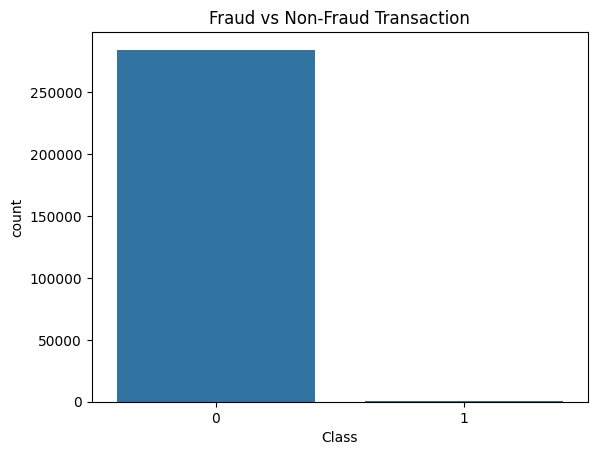

In [4]:
fraud_count = df['Class'].value_counts()
print(fraud_count)

sns.countplot(x='Class',data=df)
plt.title('Fraud vs Non-Fraud Transaction')
plt.show()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


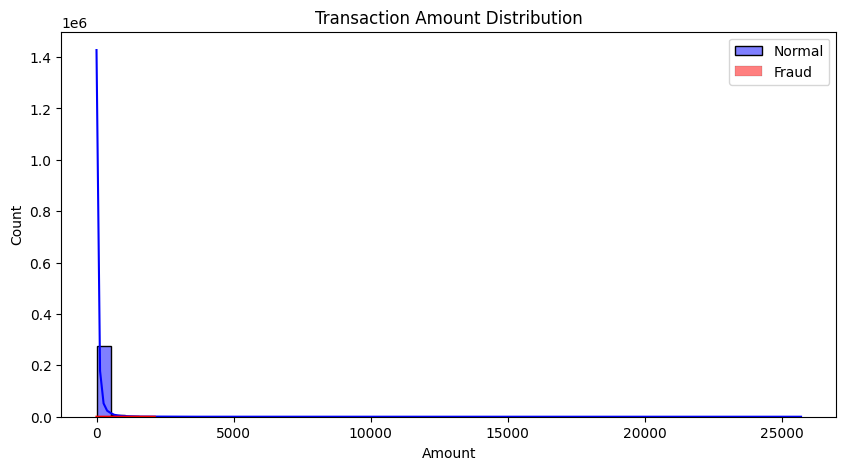

In [6]:
#separate fraud and non fraud
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(fraud['Amount'].describe())
print(normal['Amount'].describe())

plt.figure(figsize=(10,5))
sns.histplot(normal['Amount'], bins=50, color='blue', label='Normal', kde=True)
sns.histplot(fraud['Amount'], bins=50, color='red', label='Fraud', kde=True)
plt.legend()
plt.title('Transaction Amount Distribution')
plt.show()

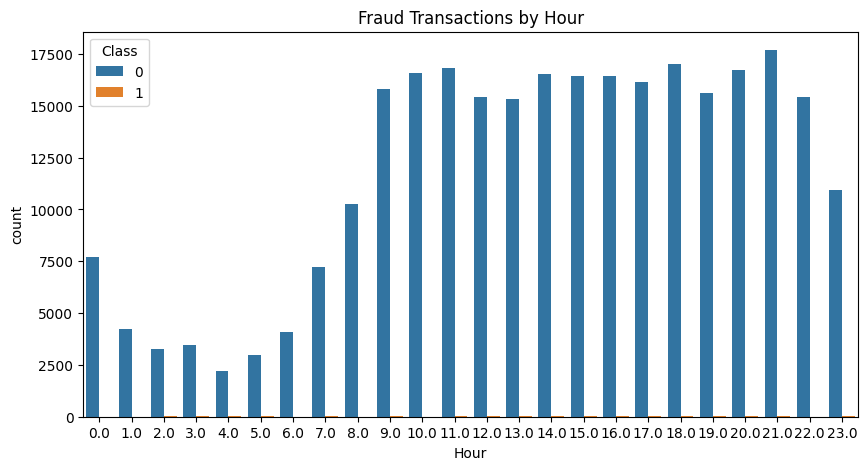

In [7]:
# Convert time to hours
df['Hour'] = (df['Time'] // 3600) % 24

# Plot fraud by hour
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df, hue='Class')
plt.title('Fraud Transactions by Hour')
plt.show()


In [8]:
# Flag high-risk transactions
df['High_Risk'] = df['Amount'] > 2000

# Check how many high-risk are fraud
print(pd.crosstab(df['High_Risk'], df['Class']))


Class           0    1
High_Risk             
False      283640  491
True          675    1


# Financial Fraud Detection & Transaction Risk Analysis
## Introduction

Financial fraud is a critical issue in digital transactions, leading to significant financial losses. 
This project aims to analyze transaction data to identify patterns and behaviors associated with fraudulent activities.

The objective is to uncover insights that can help in detecting and preventing fraud more effectively.

## Data Overview

The dataset contains 284,807 transactions with 31 features. 
There are no missing values, indicating a clean dataset suitable for analysis.

The target variable "Class" represents:
- 0: Normal transaction
- 1: Fraudulent transaction

## Fraud Distribution

Fraudulent transactions are extremely rare, with only 492 cases compared to 284,315 normal transactions.

This indicates a highly imbalanced dataset, where fraud accounts for a very small percentage of total transactions but poses significant financial risk.

## Transaction Amount Analysis

Fraudulent transactions have a higher average transaction amount (122) compared to normal transactions (88).

This suggests that fraud cases tend to involve higher financial value, increasing the potential financial impact on the business.

## Time-Based Analysis

Fraud activity appears to increase during specific hours of the day, particularly in the evening period between 7 PM and 9 PM.

This indicates the presence of time-based fraud patterns, where certain hours carry higher risk.

## Key Insights

- Fraud transactions are rare but carry high financial risk.
- Fraudulent transactions tend to involve higher amounts than normal transactions.
- Fraud activity shows patterns across different hours, indicating time-based risk.

## Recommendations

Based on the analysis, the following actions are recommended:

- Implement stricter monitoring for high-value transactions to reduce financial risk.
- Apply additional authentication measures during high-risk hours.
- Develop automated fraud detection systems based on transaction patterns.
- Continuously monitor transaction behavior to identify new fraud trends.

## Conclusion

This analysis highlights key patterns in fraudulent transactions, including higher transaction amounts and time-based activity.

By leveraging these insights, businesses can implement targeted strategies to detect and prevent fraud more effectively, reducing financial losses and improving security.
